## Plotting the curl of magnetization for different polygons

In [1]:
import numpy as np
from scipy.ndimage import label
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit


import os
import sys

In [2]:
def calc_curl(vector_list):
    x_vec = vector_list[:,:,1]
    y_vec = vector_list[:,:,0]
    dy_dx = np.gradient(y_vec, axis=0)
    dx_dy = np.gradient(x_vec, axis=1)
    curl = dy_dx - dx_dy
    return curl

In [3]:


def number_of_dommain_walls(curl_vec):
  trehshold_vec = curl_vec[curl_vec>0.0]
  labeled_wall, num_walls = label(curl_vec)
  return labeled_wall

In [4]:

def total_curl(plot=False):
  total_curl_list = []
  sides = []
  for root, dir, files in os.walk('masked_shapes'):
    print(files)
    for file in files:
      if file.split(".")[-1] == "npy":
        print(file.split())
        side = file.split(".")[0]
        print(side)
        sides.append(int(side))
        vector_field = np.squeeze((np.load(root+"/"+file)))
        print(vector_field.T[-1])
        total_curl_list.append(np.sum(np.abs(calc_curl(vector_field))))
        if plot:
          plt.imshow(calc_curl(vector_field))
          plt.show()
  sorted_sides, sorted_total_curl_list = zip(*sorted(zip(sides, total_curl_list)))
  return sorted_sides, sorted_total_curl_list

In [5]:
def calculate_mask_area(data):
    shape = np.any(data != 0, axis=2)
    area = np.sum(shape)
    return area

In [6]:
def average_curl(plot=False):
    total_curl_list = []
    sides = []
    
    for root, dir, files in os.walk('masked_shapes'):
        for file in files:
            if file.split(".")[-1] == "npy":
                side = file.split(".")[0]
                sides.append(int(side))
                vector_field = np.squeeze((np.load(root+"/"+file)))
                area = calculate_mask_area(vector_field)
                total_curl_list.append(np.sum(np.abs(calc_curl(vector_field)))/area)
                if plot:
                    plt.imshow(calc_curl(vector_field))
                    plt.show()
    sorted_sides, sorted_total_curl_list = zip(*sorted(zip(sides, total_curl_list)))
    return sorted_sides, sorted_total_curl_list

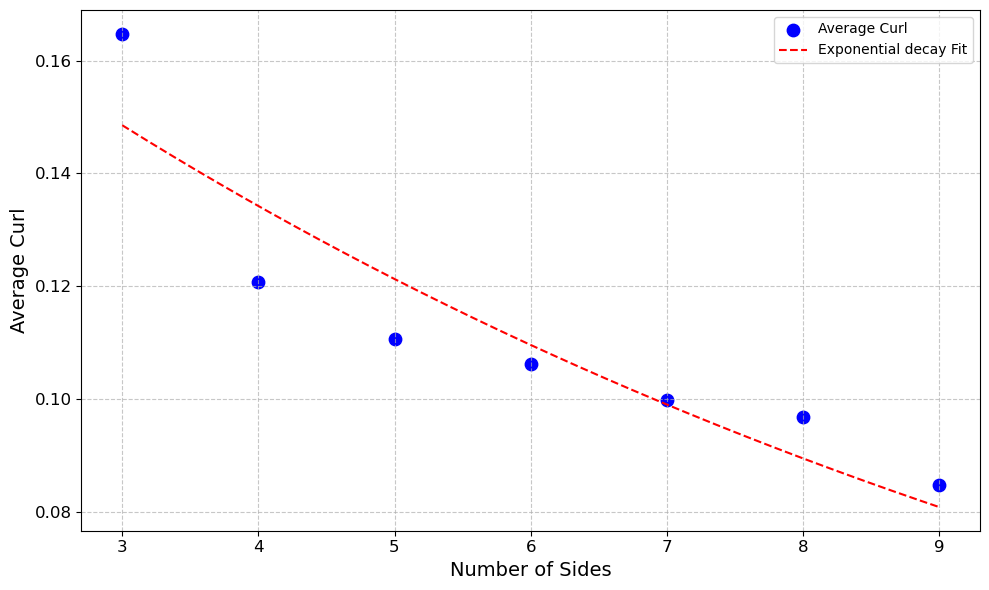

In [25]:

sides, curl_list = average_curl() #total_curl(True)

plt.figure(figsize=(10, 6))
plt.scatter(sides, curl_list, color='b', label='Average Curl', s=80)

def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

#def exponential_decay_func(x, A, k, C):
#    return A * np.exp(-k * x) + C

def exponential_decay_func(x,L,k,x0):
    return L * np.exp(-k*(x-x0))

popt, _ = curve_fit(exponential_decay_func, sides, curl_list)#, p0=[max(curl_list), 1, np.median(sides)])

x_smooth = np.linspace(min(sides), max(sides), 500)
y_smooth = exponential_decay_func(x_smooth, *popt)

plt.plot(x_smooth, y_smooth, color='r', linestyle='--', label='Exponential decay Fit')

plt.xlabel("Number of Sides", fontsize=14)
plt.ylabel("Average Curl", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("Trend.png", dpi=300)
plt.show()
